In [1]:
import matplotlib.pyplot as plt
import torch
import traceback

from classifier import *
import os, random

from collections import Counter

In [2]:
print("cwd", os.getcwd())

cwd C:\Beryllium Base\WORKSPACES\MTECH\dl-vehicles\experiments


In [4]:
model = MobileNetCNN(out_classes=4)
print(model)

print(measure_size(model))

4.23612117767334


In [4]:
dir_dataset = IMDataset(hard_limit=1000, dtype=np.float32)
pipe_dataset = PipelinedDataset(dir_dataset, simple_process_sample)
dataloader = DataLoader(pipe_dataset, batch_size=16)

In [5]:
len(dir_dataset)

1000

In [6]:
freqs: dict[int, int] = {}

for x in dir_dataset:
    idx = class_to_idx[x[0]['label']]
    freqs[idx] = freqs.get(idx, 0) + 1

Counter(freqs)

Counter({3: 250, 0: 250, 1: 250, 2: 250})

In [7]:
try:
    print(len([_ for _ in dataloader]))
except:
    traceback.print_exc()

63


In [9]:
freqs: dict[int, int] = {}

for sample in dataloader:
    for label in sample[1][:, 1]:
        label = int(label)
        freqs[label] = freqs.get(label, 0) + 1

Counter(freqs)

Counter({3: 250, 0: 250, 1: 250, 2: 250})

In [10]:
print(next(iter(dataloader))[0].max())

tensor(1.)


In [11]:
cel = nn.CrossEntropyLoss()

class ContextfulLoss(nn.Module):
    def forward(self, logits, targets):
        targets = targets[:, 1]
        return cel(logits, targets)

In [12]:
trainer = Trainer(
    model=model,
    train_dataloader=dataloader,
    # criterion = nn.CrossEntropyLoss(),
    criterion=ContextfulLoss(),
    optimizer=lambda params: torch.optim.Adam(params, lr=0.003),
    epochs=5,
)

In [13]:
try:
    trainer.train()
except:
    traceback.print_exc()

Epoch:  1/ 5    Train Loss: 0.47    TTS: 7.73    ETA: 30.91
Epoch:  2/ 5    Train Loss: 0.20    TTS: 13.60    ETA: 20.40
Epoch:  3/ 5    Train Loss: 0.14    TTS: 20.20    ETA: 13.47
Epoch:  4/ 5    Train Loss: 0.11    TTS: 26.83    ETA: 6.71
Epoch:  5/ 5    Train Loss: 0.09    TTS: 32.86    ETA: 0.00


tensor([1, 3])
index 3
class motorcycle


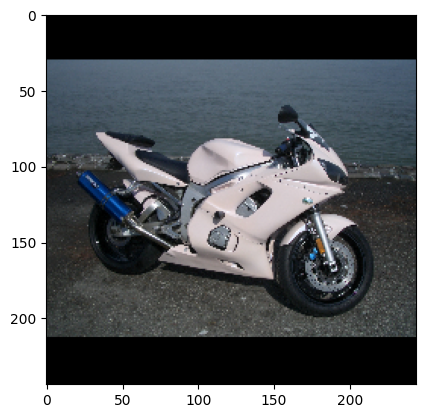

In [14]:
test_sample = None
for sample in dataloader:
    test_sample = sample
    if random.randint(1, 10) == 1:
        break

idx = random.randint(0, len(test_sample[0])-1)
sample_i = (255*test_sample[0][idx].detach().numpy().transpose(1, 2, 0)).astype(np.uint8)
print(test_sample[1][idx])
print("index", test_sample[1][idx][1].detach().item())
print("class", idx_to_class[int(test_sample[1][idx][1].detach().item())])

try:
    plt.imshow(sample_i)
except Exception as e:
    print(e)
    pass

In [19]:
with torch.no_grad():
    # print(test_sample[0][0:1].shape)
    thing = model(test_sample[0][0:1]).detach().numpy()
    print(thing)
    print(thing.mean(), thing.std())
    print(thing.argmax())
    print(idx_to_class[int(thing.argmax())])

[[-2.7536447  1.6553106  1.0059161  2.4865985]]
0.59854513 2.0052822
3
motorcycle


In [16]:
with torch.no_grad():
    # print(test_sample[0][0:1].shape)
    thing = model(test_sample[0][0:1])
    print(thing)
    print(thing.argmax())

tensor([[-2.1564,  1.6902,  0.9814,  2.3355]])
tensor(3)


In [42]:
try:
    with torch.no_grad():
        # print(test_sample[0][0:1].shape)
        thing = model(test_sample[0])
        # print(thing)
        print(thing.argmax(axis=1))
except:
    pass

tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])
